# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  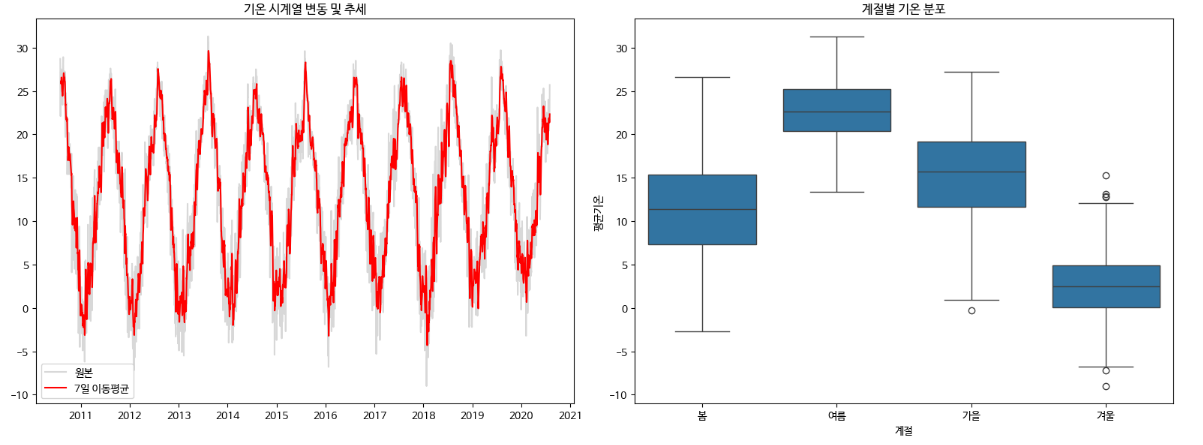

  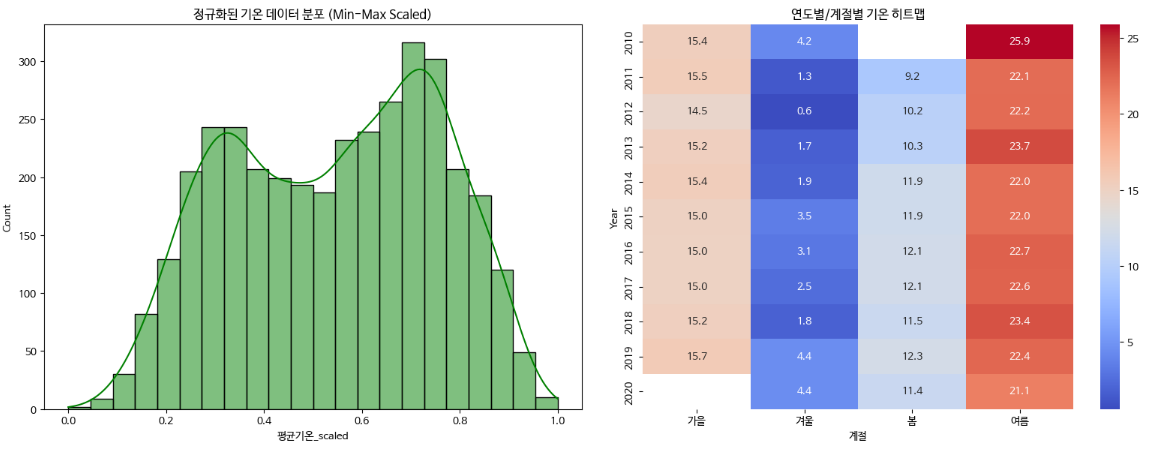



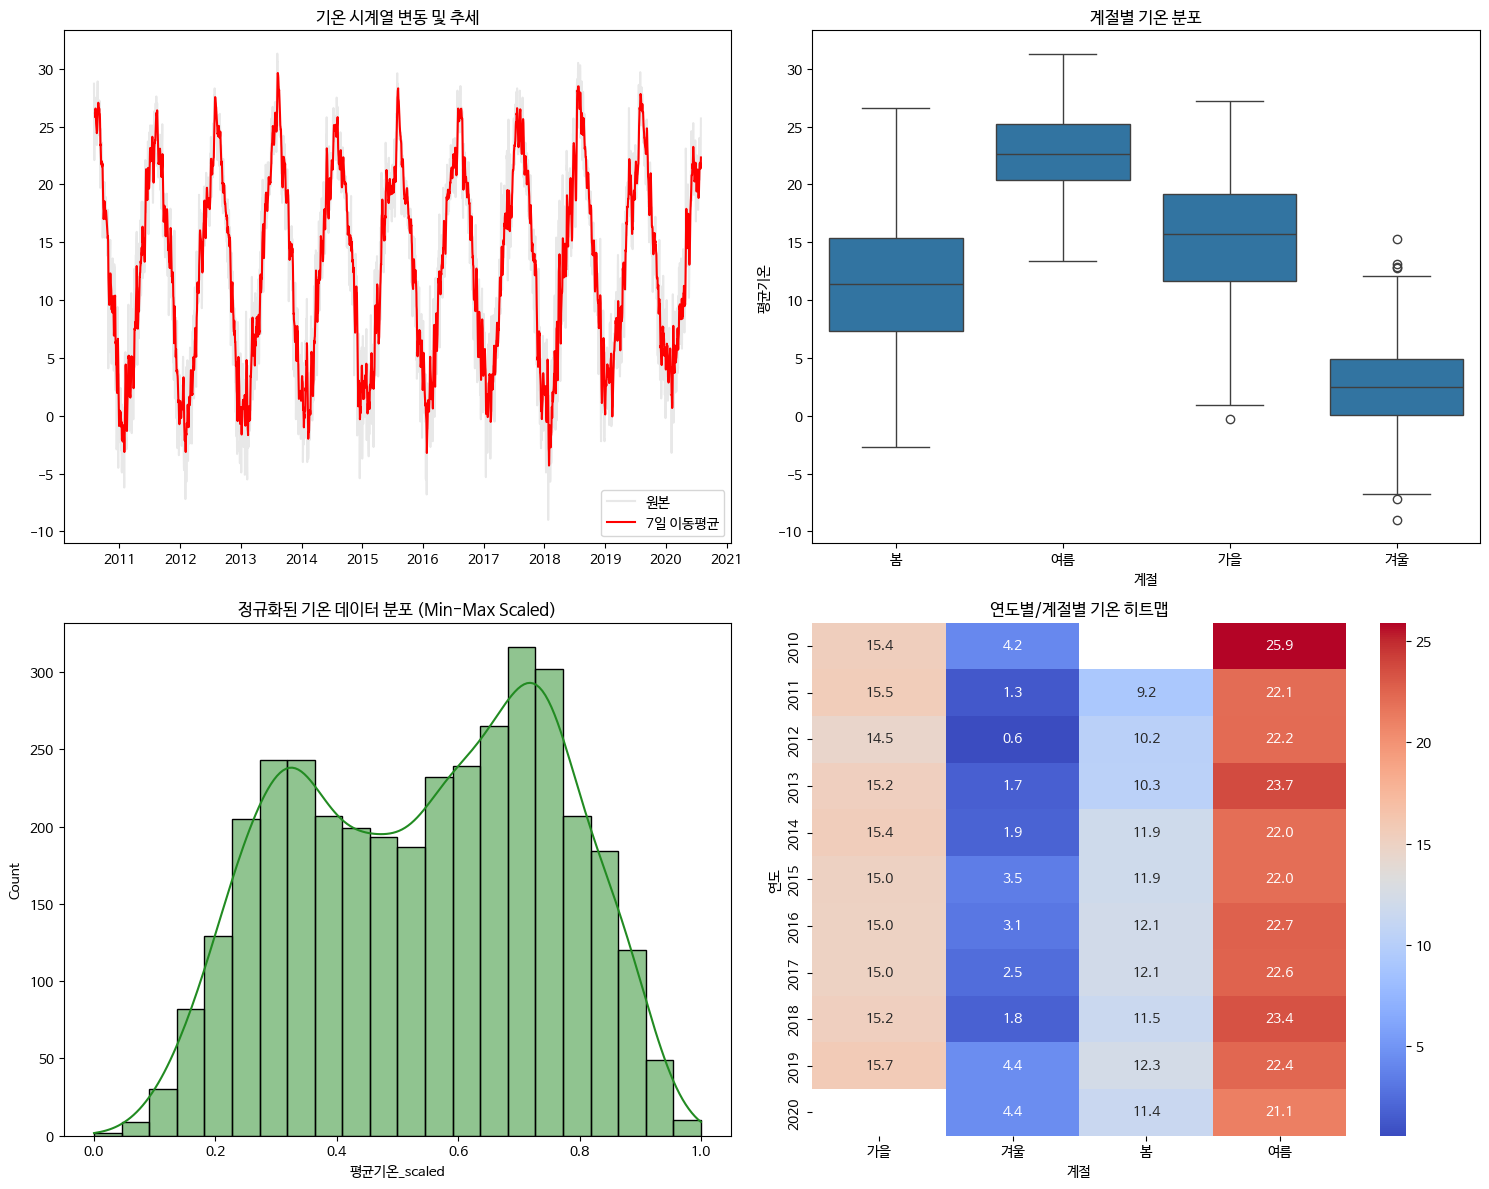

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

def setup_environment():
    warnings.filterwarnings('ignore')
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False

def load_and_preprocess(url):
    df = pd.read_csv(url, encoding='CP949')
    df['일시'] = pd.to_datetime(df['일시'])
    df = df.sort_values('일시')

    # 7일 이동 평균 및 계절 변수 생성
    df['7일_이동평균'] = df['평균기온'].rolling(window=7).mean()
    df['연도'] = df['일시'].dt.year
    df['월'] = df['일시'].dt.month

    def get_season(m):
        if m in [12, 1, 2]: return '겨울'
        elif m in [3, 4, 5]: return '봄'
        elif m in [6, 7, 8]: return '여름'
        else: return '가을'
    df['계절'] = df['월'].apply(get_season)

    return df

def apply_min_max_scaling(df, column):
    c_min = df[column].min()
    c_max = df[column].max()
    df[f'{column}_scaled'] = (df[column] - c_min) / (c_max - c_min)
    return df

def restructure_data(df):
    seasonal_stats = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()
    pivot_table = df.pivot_table(index='연도', columns='계절', values='평균기온', aggfunc='mean')
    pivot_table = pivot_table[['가을', '겨울', '봄', '여름']]
    return seasonal_stats, pivot_table

def create_visualizations(df, pivot_df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 시계열 추세
    axes[0, 0].plot(df['일시'], df['평균기온'], color='lightgray', label='원본', alpha=0.5)
    axes[0, 0].plot(df['일시'], df['7일_이동평균'], color='red', label='7일 이동평균')
    axes[0, 0].set_title("기온 시계열 변동 및 추세")
    axes[0, 0].legend()

    # 계절별 분포
    sns.boxplot(x='계절', y='평균기온', data=df, ax=axes[0, 1], order=['봄', '여름', '가을', '겨울'])
    axes[0, 1].set_title("계절별 기온 분포")

    # 정규화 데이터 분포
    sns.histplot(df['평균기온_scaled'], kde=True, color='forestgreen', ax=axes[1, 0])
    axes[1, 0].set_title("정규화된 기온 데이터 분포 (Min-Max Scaled)")

    # 히트맵
    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title("연도별/계절별 기온 히트맵")

    plt.tight_layout()
    plt.show()

def main():
    setup_environment()
    url = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'

    # 파이프라인 실행
    weather_df = load_and_preprocess(url)
    weather_df = apply_min_max_scaling(weather_df, '평균기온')
    seasonal_stats, yearly_pivot = restructure_data(weather_df)

    # 시각화 및 저장
    create_visualizations(weather_df, yearly_pivot)

    output_file = "weather_analysis_report.xlsx"
    with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
        weather_df.to_excel(writer, sheet_name='전처리_데이터', index=False)
        seasonal_stats.to_excel(writer, sheet_name='계절별_통계')
        yearly_pivot.to_excel(writer, sheet_name='연도별_피벗_테이블')

if __name__ == "__main__":
    main()